# 01 · Exploratory analysis of NASA C-MAPSS

Run `make data` first. This notebook motivates the choices in `sentinel.evaluation.cmapss`:
the 125-cycle RUL cap, dropping quantized sensors, and per-regime normalization for FD002/FD004.
All logic lives in the package (tested); the notebook only calls it and plots.

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np

ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
sys.path.insert(0, str(ROOT / "src"))
DATA = ROOT / "data" / "reference"
REPORTS = ROOT / "reports"

# Reference categorical palette (fixed order) and recessive chart chrome.
BLUE, ORANGE, AQUA = "#2a78d6", "#eb6834", "#1baf7a"
plt.rcParams.update({
    "figure.dpi": 110, "figure.facecolor": "#fcfcfb", "axes.facecolor": "#fcfcfb",
    "axes.edgecolor": "#c9c8c2", "axes.grid": True, "grid.color": "#e6e5e0", "grid.linewidth": 0.6,
    "axes.spines.top": False, "axes.spines.right": False, "lines.linewidth": 2,
    "axes.titleweight": "bold", "axes.titlesize": 11, "axes.labelcolor": "#52514e",
    "xtick.color": "#52514e", "ytick.color": "#52514e", "legend.frameon": False,
})

In [2]:
from sentinel.datasets import load_cmapps_arrays
from sentinel.evaluation.cmapss import FeatureConfig, OfflineFeatureBuilder

DOMAINS = ("FD001", "FD002", "FD003", "FD004")
train = {d: load_cmapps_arrays(DATA / f"train_{d}.txt", d) for d in DOMAINS}
test = {d: load_cmapps_arrays(DATA / f"test_{d}.txt", d, DATA / f"RUL_{d}.txt") for d in DOMAINS}
for d in DOMAINS:
    life = np.array([train[d].cycle[train[d].engine == e].max() for e in np.unique(train[d].engine)])
    print(f"{d}: {len(train[d]):>6,} train rows, {len(life):>3} engines, life {life.min()}-{life.max()} "
          f"(median {np.median(life):.0f}); test: {test[d].last_cycle_mask().sum()} engines, "
          f"terminal RUL median {np.median(test[d].rul[test[d].last_cycle_mask()]):.0f}")

FD001: 20,631 train rows, 100 engines, life 128-362 (median 199); test: 100 engines, terminal RUL median 86
FD002: 53,759 train rows, 260 engines, life 128-378 (median 199); test: 259 engines, terminal RUL median 80
FD003: 24,720 train rows, 100 engines, life 145-525 (median 220); test: 100 engines, terminal RUL median 78
FD004: 61,249 train rows, 249 engines, life 128-543 (median 234); test: 248 engines, terminal RUL median 88


## Engine lifetimes and the test-set evaluation point

Test trajectories are truncated well before failure. Most terminal RULs are below ~125, which is
why the capped (piecewise-linear) target is the standard choice.

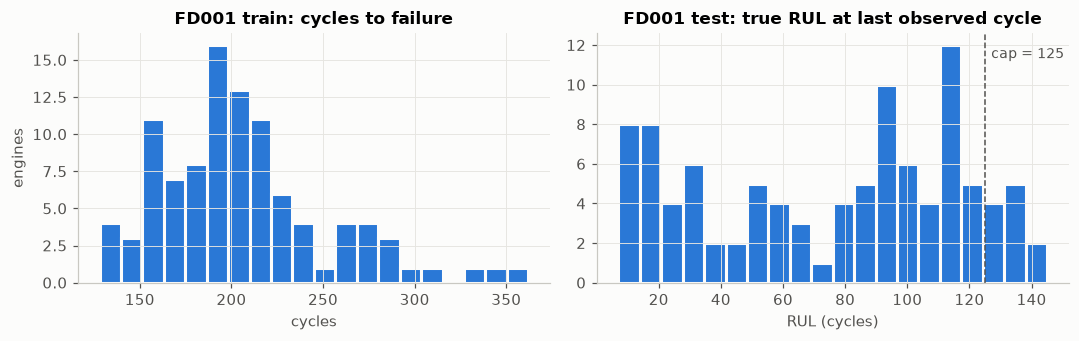

In [3]:
fig, axes = plt.subplots(1, 2, figsize=(10, 3.2))
life = [train["FD001"].cycle[train["FD001"].engine == e].max() for e in np.unique(train["FD001"].engine)]
axes[0].hist(life, bins=20, color=BLUE, edgecolor="#fcfcfb", linewidth=2)
axes[0].set(title="FD001 train: cycles to failure", xlabel="cycles", ylabel="engines")
last = test["FD001"].last_cycle_mask()
axes[1].hist(test["FD001"].rul[last], bins=20, color=BLUE, edgecolor="#fcfcfb", linewidth=2)
axes[1].axvline(125, color="#52514e", linestyle="--", linewidth=1)
axes[1].text(127, axes[1].get_ylim()[1] * 0.9, "cap = 125", color="#52514e", fontsize=9)
axes[1].set(title="FD001 test: true RUL at last observed cycle", xlabel="RUL (cycles)")
plt.tight_layout()

## Which sensors carry signal?

A channel is kept only if it takes at least 10 distinct values inside some operating regime.

In [4]:
for d in DOMAINS:
    builder = OfflineFeatureBuilder(FeatureConfig(regimes=6 if d in ("FD002", "FD004") else 1, rolling=())).fit(train[d])
    kept = [n for n in builder.names if n != "cycle"]
    dropped = sorted(set(f"s{i}" for i in range(1, 22)) - set(kept), key=lambda s: int(s[1:]))
    print(f"{d}: keep {len(kept)} -> {', '.join(kept)}\n       drop {', '.join(dropped)}")

FD001: keep 14 -> s2, s3, s4, s7, s8, s9, s11, s12, s13, s14, s15, s17, s20, s21
       drop s1, s5, s6, s10, s16, s18, s19
FD002: keep 14 -> s2, s3, s4, s7, s8, s9, s11, s12, s13, s14, s15, s17, s20, s21
       drop s1, s5, s6, s10, s16, s18, s19
FD003: keep 15 -> s2, s3, s4, s6, s7, s8, s9, s11, s12, s13, s14, s15, s17, s20, s21
       drop s1, s5, s10, s16, s18, s19


FD004: keep 15 -> s2, s3, s4, s6, s7, s8, s9, s11, s12, s13, s14, s15, s17, s20, s21
       drop s1, s5, s10, s16, s18, s19


## Degradation trends (FD001)

Normalized sensors drift monotonically toward failure, but single-cycle readings are noisy;
rolling statistics recover the trend.

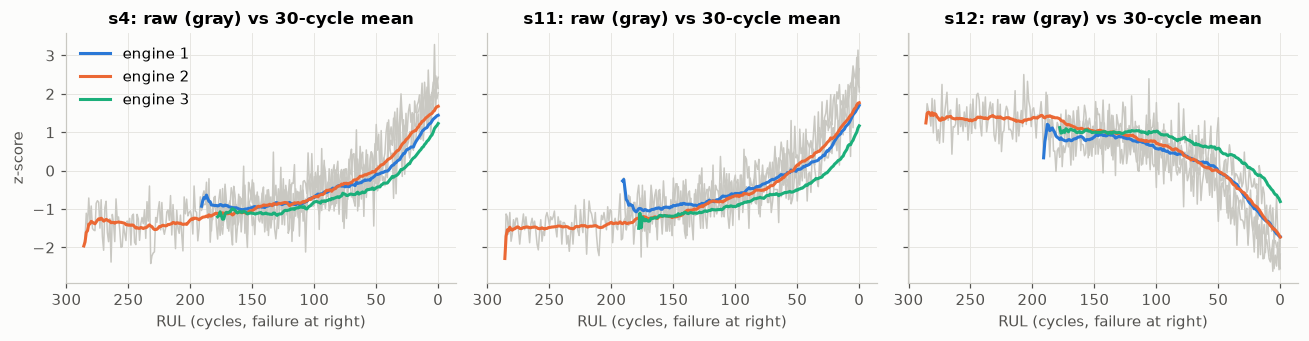

In [5]:
data = train["FD001"]
builder = OfflineFeatureBuilder(FeatureConfig(rolling=("mean",), window=30)).fit(data)
x = builder.transform(data)
fig, axes = plt.subplots(1, 3, figsize=(12, 3.2), sharey=True)
for ax, sensor in zip(axes, ("s4", "s11", "s12")):
    raw, smooth = builder.names.index(sensor), builder.names.index(f"{sensor}_mean30")
    for engine, alpha in ((1, 1.0), (2, 1.0), (3, 1.0)):
        mask = data.engine == engine
        ax.plot(data.rul[mask], x[mask, raw], color="#c9c8c2", linewidth=1)
    for engine, color in ((1, BLUE), (2, ORANGE), (3, AQUA)):
        mask = data.engine == engine
        ax.plot(data.rul[mask], x[mask, smooth], color=color, label=f"engine {engine}")
    ax.invert_xaxis()
    ax.set(title=f"{sensor}: raw (gray) vs 30-cycle mean", xlabel="RUL (cycles, failure at right)")
axes[0].set_ylabel("z-score")
axes[0].legend(loc="upper left")
plt.tight_layout()

## Why FD002/FD004 need per-regime normalization

Six flight conditions dominate the raw sensor values; the degradation signal is invisible until
each regime is normalized separately (k-means on the three settings, fitted on training data).

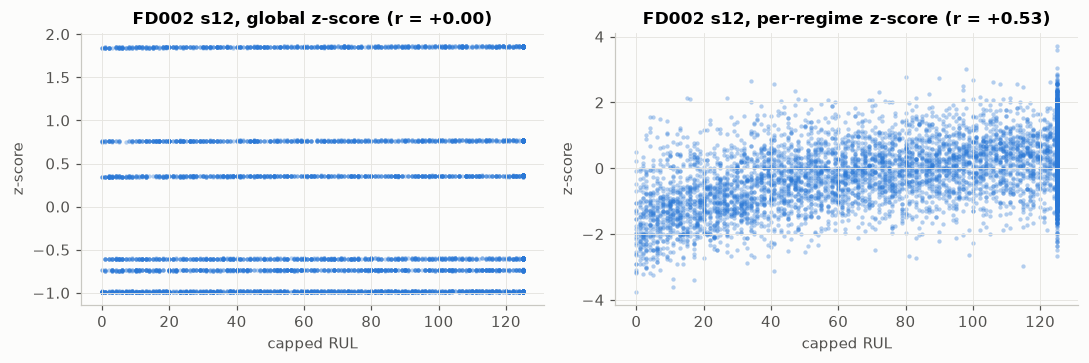

In [6]:
data = train["FD002"]
column = 11  # s12 (0-based)
flat = OfflineFeatureBuilder(FeatureConfig(regimes=1, rolling=())).fit(data)
regime = OfflineFeatureBuilder(FeatureConfig(regimes=6, rolling=())).fit(data)
capped = np.minimum(data.rul, 125)
fig, axes = plt.subplots(1, 2, figsize=(10, 3.4))
for ax, builder, title in ((axes[0], flat, "global z-score"), (axes[1], regime, "per-regime z-score")):
    values = builder.transform(data)[:, builder.names.index("s12")]
    ax.scatter(capped[::7], values[::7], s=8, color=BLUE, alpha=0.35, linewidths=0)
    corr = np.corrcoef(values, capped)[0, 1]
    ax.set(title=f"FD002 s12, {title} (r = {corr:+.2f})", xlabel="capped RUL", ylabel="z-score")
plt.tight_layout()